In [5]:
import os, sys
sys.path.append(os.getcwd())
print(f"current work dir is {os.getcwd()}")
from setting.global_dirs import *
from setting.variables_config import *
from scripts.analysis.functions_for_visualization import *
from setting.basic_functions import *

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
# get number of courses in dic
data_version_dic = "./data_container/25_11_19_20_02_55/"
df_full = load_drps_full_df(data_version_dic)
num_courses_in_schools = get_number_of_courses_per_school(df_full)

current work dir is /Users/ruanxingran/git_repos/ptas


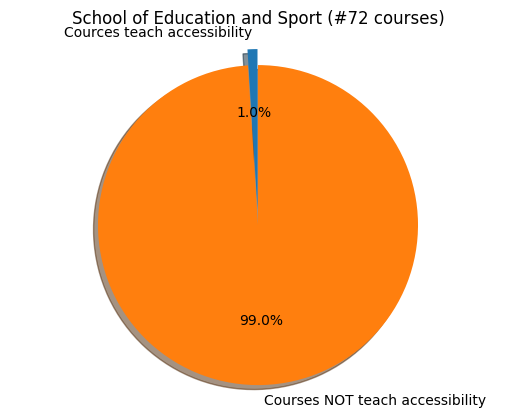

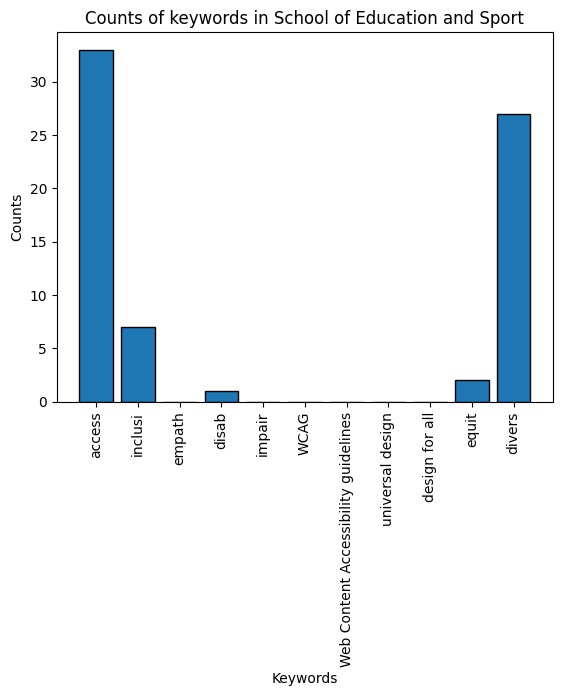

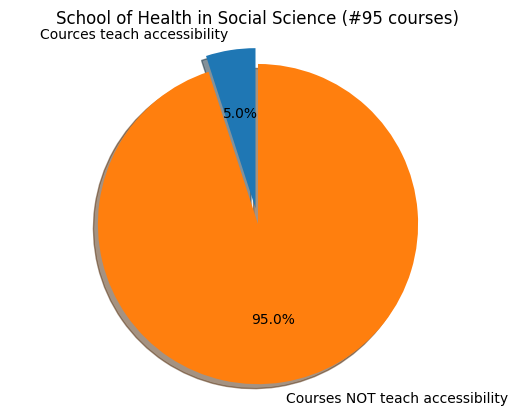

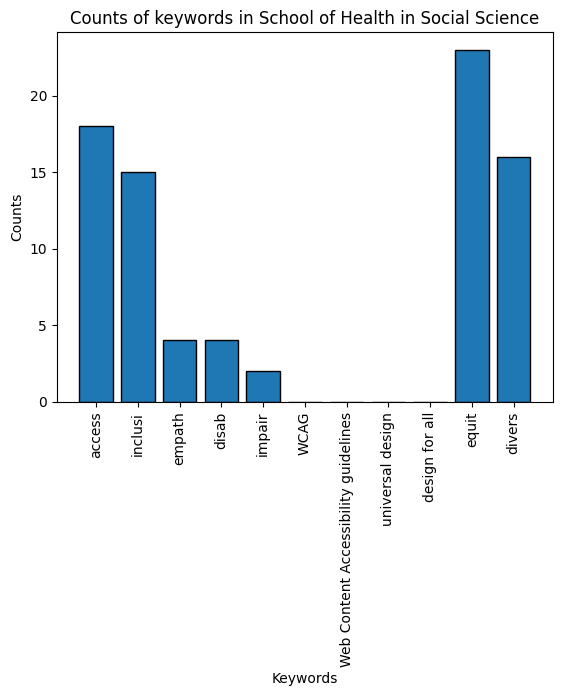

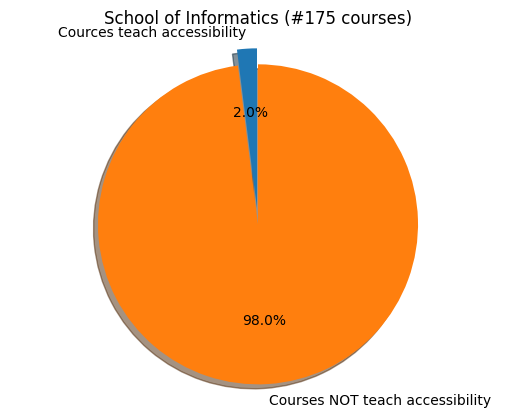

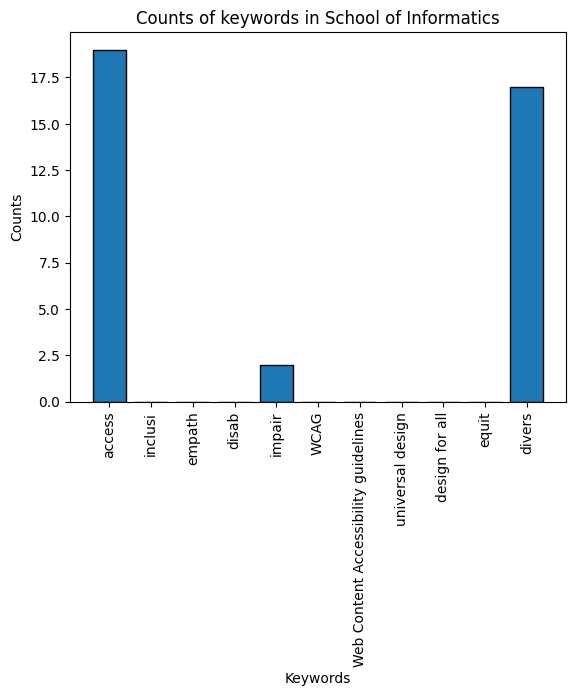

In [ ]:
match_condition_list = ["access", "inclusi", "empath", "disab", "impair" , "WCAG", "Web Content Accessibility guidelines", "universal design", "design for all", "equit", "divers"]
DRPS_results = pd.read_excel("./data_container/DeskResearch_Results/1.DRPS_results.xlsx")
cols_courses_and_yesorno = ["School", "Course title", "CheckSummary (0:irrelevant 1:relevant)", "CheckCourseDescription (0:irrelevant 1:relevant)", "CheckLearningOutcomes (0:irrelevant 1:relevant)", "CheckGraduateAttributesandSkills  (0:irrelevant 1:relevant)", "CheckKeywords  (0:irrelevant 1:relevant)"]

accessibility_check_cols = ["CheckSummary (0:irrelevant 1:relevant)", "CheckCourseDescription (0:irrelevant 1:relevant)", "CheckLearningOutcomes (0:irrelevant 1:relevant)", "CheckGraduateAttributesandSkills  (0:irrelevant 1:relevant)", "CheckKeywords  (0:irrelevant 1:relevant)"]
course_attributes = ["Summary", "Course description", "Learning Outcomes", "Graduate Attributes and Skills", "Keywords"]

for school in num_courses_in_schools.keys():
    num_courses = num_courses_in_schools[school]
    num_courses_have_accessibility_info = get_num_courses_in_schools_have_accessibility_info(DRPS_results, accessibility_check_cols, school)
    plot_pie_percentage_course_have_accessibility(title=f"{school} (#{num_courses} courses)", percentage=num_courses_have_accessibility_info/num_courses, labels=["Cources teach accessibility", "Courses NOT teach accessibility"])
    
    times_of_accessibility_info = get_times_of_accessibility_info_in_schools(DRPS_results, course_attributes, school, match_condition_list)
    plot_histogram_times_of_accessibility_info(title=f"Counts of keywords in {school}", rt_words_times=times_of_accessibility_info)

In [7]:
from docx import Document
from docx.oxml.ns import qn
from docx.oxml import OxmlElement
import re

In [8]:
def set_highlight_run(run, color):
    """ Function to set the highlight color of a run. """
    r = run._element
    highlight = OxmlElement('w:highlight')
    highlight.set(qn('w:val'), color)
    r.append(highlight)

def contains_word(s, word):
    """Check if 'word' is in 's' ignoring case."""
    return word.lower() in s.lower()

def highlight_words(document, word_color_pairs):
    """ Highlight words in the document with specified colors, ignoring case. """
    for paragraph in document.paragraphs:
        for run in paragraph.runs:
            run_text_lower = run.text.lower()  # Convert text in run to lowercase
            for word, color in word_color_pairs.items():
                result = contains_word(run_text_lower, word)
                if result:
                    # Only highlight if the word is in the run's text
                    original_words = run.text.split()
                    colored_words = ' '
                    for each_word in original_words:
                        if re.sub(r'[^a-zA-Z0-9\s]', '', each_word.lower()) == word.lower():
                            colored_words = colored_words.join(set_highlight_run(each_word, color))
                    
                    run.text = colored_words

def set_highlight_run(word, color):
    """ Returns a string with highlight tags around a word """
    return f'{word}'  # Simplified for demonstration; actual highlighting logic differs in XML context.


In [9]:
def add_color_description_in_Word(doc, word_color_pair):
    para = doc.paragraphs[0].insert_paragraph_before()
    
    for each_word, each_color in zip(list(word_color_pair.keys()), list(word_color_pair.values())):
        run = para.add_run(f"{each_word}; ")
        run.font.color.rbg = each_color

In [ ]:
doc = Document('./data_container/Interviews/PTAS interview - Ben, alumnus.docx')
# Define words and their corresponding highlight colors
word_color_pairs = Student_words_colors_pair.copy()
add_color_description_in_Word(doc, word_color_pairs)
# Highlight words in the document
highlight_words(doc, word_color_pairs)

# Save the modified document
doc.save('./bin/qualitative_results/highlighted_document.docx')